# Project: PCE Growth Regime Classification and Economic Feature Discovery

## Step 1 — PCE Target Distribution & Classification Target Design

### 1A. Load and inspect the target

In [2]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
filename = Path("data") / "pce_growth_target.csv"
model_df = pd.read_csv(filename,parse_dates=["DATE"])

In [4]:
model_df.head(2)

,DATE,Real_PCE,Real_PCE_Growth_QoQ
0,2007-06-30,11218.5,0.248421
1,2007-09-30,11309.6,0.812052


In [5]:
model_df.tail(2)

,DATE,Real_PCE,Real_PCE_Growth_QoQ
75,2026-03-31,16730.1,0.296151
76,2026-06-30,16885.2,0.927072


In [6]:
model_df.shape

(77, 3)

In [7]:
TARGET = "Real_PCE_Growth_QoQ"

In [8]:
df=model_df.copy()

In [9]:
print("Dataset shape:", df.shape)
print("\nTarget:", TARGET)
print("\nFirst observations:")
print(df[TARGET].head(10))

print("\nTarget data type:")
print(df[TARGET].dtype)

print("\nMissing target values:")
print(df[TARGET].isna().sum())

Dataset shape: (77, 3)

Target: Real_PCE_Growth_QoQ

First observations:
0    0.248421
1    0.812052
2    0.225472
3   -0.114688
4    0.164280
5   -1.155132
6   -0.748459
7   -0.370310
8   -0.031575
9    0.302317
Name: Real_PCE_Growth_QoQ, dtype: float64

Target data type:
float64

Missing target values:
0


### 1B. Descriptive statistics

In [10]:
target_stats = df[TARGET].describe()

In [11]:
print("PCE Growth Descriptive Statistics")
print("=" * 40)
print(target_stats)

print("\nAdditional statistics")
print("=" * 40)
print(f"Median:   {df[TARGET].median():.4f}")
print(f"Std Dev:  {df[TARGET].std():.4f}")
print(f"Minimum:  {df[TARGET].min():.4f}")
print(f"Maximum:  {df[TARGET].max():.4f}")
print(f"Skewness: {df[TARGET].skew():.4f}")

PCE Growth Descriptive Statistics
count    77.000000
mean      0.541667
std       1.095797
min      -6.470559
25%       0.286710
50%       0.564123
75%       0.826364
max       4.657546
Name: Real_PCE_Growth_QoQ, dtype: float64

Additional statistics
Median:   0.5641
Std Dev:  1.0958
Minimum:  -6.4706
Maximum:  4.6575
Skewness: -2.5745


Text(0, 0.5, 'PCE Growth rate')

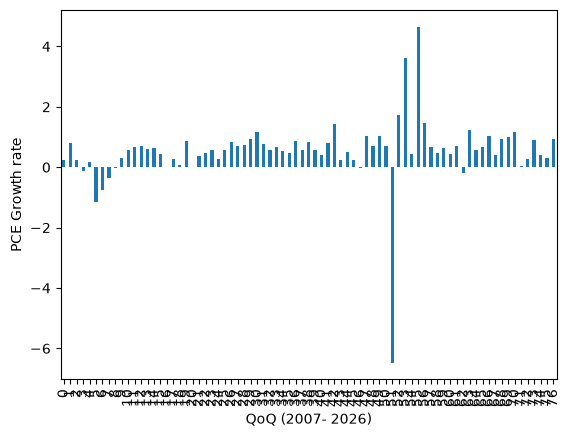

In [12]:
df[TARGET].plot.bar()
plt.xlabel("QoQ (2007- 2026)")
plt.ylabel("PCE Growth rate")

### 1C. Examine positive and negative PCE growth

*PCE Growth ≤ 0*  vs  *PCE Growth > 0*

In [13]:
negative = (df[TARGET] < 0).sum()
zero = (df[TARGET] == 0).sum()
positive = (df[TARGET] > 0).sum()

total = df[TARGET].notna().sum()

growth_summary = pd.DataFrame({
    "Group": [
        "Negative PCE Growth",
        "Zero PCE Growth",
        "Positive PCE Growth"
    ],
    "Count": [
        negative,
        zero,
        positive
    ]
})

growth_summary["Percentage"] = (
    growth_summary["Count"] / total * 100
).round(2)

print(growth_summary)

                 Group  Count  Percentage
0  Negative PCE Growth     10       12.99
1      Zero PCE Growth      0        0.00
2  Positive PCE Growth     67       87.01


#### Comments: 
The result is imbalanced for the primary classification target.
- Negative: 10
- Positive: 67


### 1D. Examine candidate statistical thresholds

In [14]:
candidate_thresholds = pd.Series({
    "Zero": 0,
    "25th Percentile": df[TARGET].quantile(0.25),
    "Median": df[TARGET].median(),
    "75th Percentile": df[TARGET].quantile(0.75),
    "Mean": df[TARGET].mean()
})

print("Candidate PCE Classification Thresholds")
print("=" * 45)
print(candidate_thresholds)

Candidate PCE Classification Thresholds
Zero               0.000000
25th Percentile    0.286710
Median             0.564123
75th Percentile    0.826364
Mean               0.541667
dtype: float64


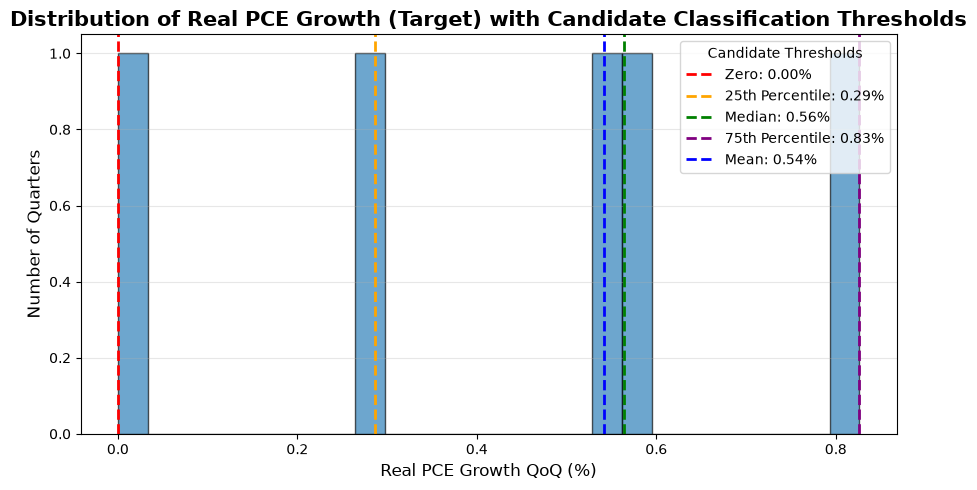

In [15]:
# Visualized 

fig, ax = plt.subplots(figsize=(9, 5))
ax.hist(candidate_thresholds,bins=25,alpha=0.65,edgecolor="black")

# Add candidate threshold lines
colors = [
    "red",
    "orange",
    "green",
    "purple",
    "blue"
]

for (name, value), color in zip(candidate_thresholds.items(), colors):

    ax.axvline(
        value,
        color=color,
        linestyle="--",
        linewidth=2,
        label=f"{name}: {value:.2f}%"
    )

ax.set_title(
    "Distribution of Real PCE Growth (Target) with Candidate Classification Thresholds",
    fontsize=15,
    fontweight="bold"
)

ax.set_xlabel(
    "Real PCE Growth QoQ (%)",
    fontsize=12
)

ax.set_ylabel(
    "Number of Quarters",
    fontsize=12
)

ax.legend(
    title="Candidate Thresholds",
    fontsize=10
)

ax.grid(
    axis="y",
    alpha=0.3
)

plt.tight_layout()
plt.show()

evaluate the resulting class balance

In [16]:
threshold_results = []

for name, threshold in candidate_thresholds.items():

    low_count = (df[TARGET] <= threshold).sum()
    high_count = (df[TARGET] > threshold).sum()

    threshold_results.append({
        "Threshold_Method": name,
        "Threshold": threshold,
        "Class_0_Count": low_count,
        "Class_1_Count": high_count,
        "Class_0_Percent": low_count / total * 100,
        "Class_1_Percent": high_count / total * 100
    })

threshold_results = pd.DataFrame(threshold_results)

print(
    threshold_results.round({
        "Threshold": 4,
        "Class_0_Percent": 2,
        "Class_1_Percent": 2
    })
)

  Threshold_Method  Threshold  Class_0_Count  Class_1_Count  Class_0_Percent  \
0             Zero     0.0000             10             67            12.99   
1  25th Percentile     0.2867             20             57            25.97   
2           Median     0.5641             39             38            50.65   
3  75th Percentile     0.8264             58             19            75.32   
4             Mean     0.5417             33             44            42.86   

   Class_1_Percent  
0            87.01  
1            74.03  
2            49.35  
3            24.68  
4            57.14  


**Result:**

|Threshold values | Threshold       | Weak PCE | Strong PCE |
|------------| --------------- | -------: | ---------: |
|0.0000      | Zero           | Too Few (12.99%) | Too Many (87.01%)|
|0.2867      | 25th percentile   | Low (25.97%) | High (74.03%)|
|0.5641     | Median         | Balanced (50.65%) | Balanced (49.35%)|
|0.8264     | 75th percentile | Too Many (75.32%) | Too Few (24.68%)|
| 0.5417    | Mean           | Balanced (42.86%) | Balanced (57.14%)|


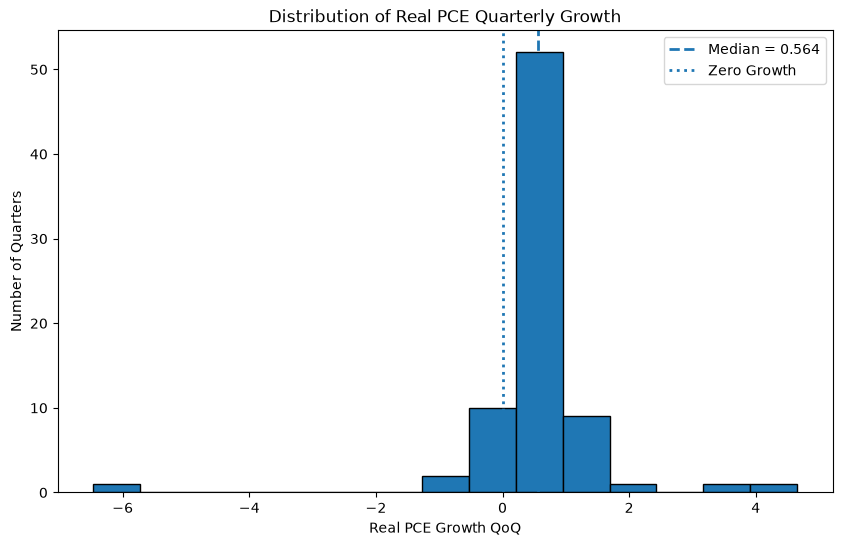

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.hist(
    df[TARGET].dropna(),
    bins=15,
    edgecolor="black"
)

ax.axvline(
    df[TARGET].median(),
    linestyle="--",
    linewidth=2,
    label=f"Median = {df[TARGET].median():.3f}"
)

ax.axvline(
    0,
    linestyle=":",
    linewidth=2,
    label="Zero Growth"
)

ax.set_title("Distribution of Real PCE Quarterly Growth")
ax.set_xlabel("Real PCE Growth QoQ")
ax.set_ylabel("Number of Quarters")

ax.legend()

plt.show()

### 1F — Inspect PCE through time

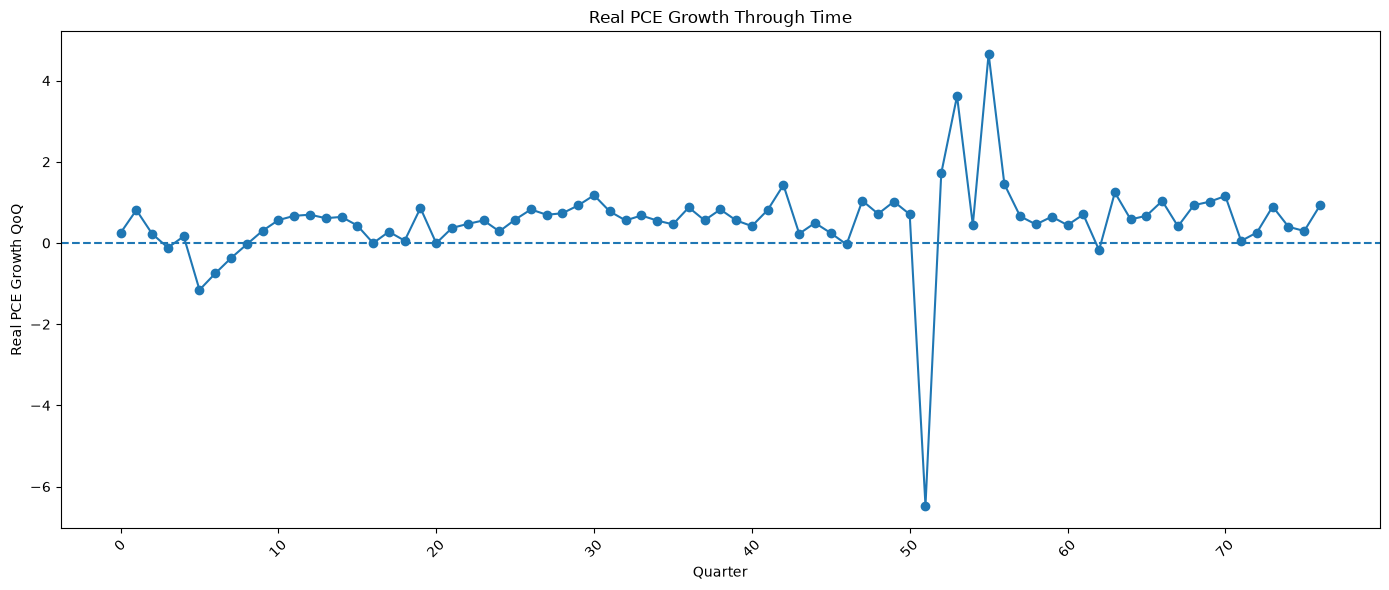

In [18]:
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    df.index,
    df[TARGET],
    marker="o"
)

ax.axhline(
    y=0,
    linestyle="--"
)

ax.set_title("Real PCE Growth Through Time")
ax.set_xlabel("Quarter")
ax.set_ylabel("Real PCE Growth QoQ")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 1G — Preserve chronology before choosing the threshold

Assuming our established split remains 2021/2022:

In [19]:
# Convert DATE to datetime
df["DATE"] = pd.to_datetime(df["DATE"])

# Set DATE as the dataframe index
df = df.set_index("DATE")

# Make sure observations are chronological
df = df.sort_index()

print(df.index)
print(df.index.dtype)

display(df.head())

DatetimeIndex(['2007-06-30', '2007-09-30', '2007-12-31', '2008-03-31',
               '2008-06-30', '2008-09-30', '2008-12-31', '2009-03-31',
               '2009-06-30', '2009-09-30', '2009-12-31', '2010-03-31',
               '2010-06-30', '2010-09-30', '2010-12-31', '2011-03-31',
               '2011-06-30', '2011-09-30', '2011-12-31', '2012-03-31',
               '2012-06-30', '2012-09-30', '2012-12-31', '2013-03-31',
               '2013-06-30', '2013-09-30', '2013-12-31', '2014-03-31',
               '2014-06-30', '2014-09-30', '2014-12-31', '2015-03-31',
               '2015-06-30', '2015-09-30', '2015-12-31', '2016-03-31',
               '2016-06-30', '2016-09-30', '2016-12-31', '2017-03-31',
               '2017-06-30', '2017-09-30', '2017-12-31', '2018-03-31',
               '2018-06-30', '2018-09-30', '2018-12-31', '2019-03-31',
               '2019-06-30', '2019-09-30', '2019-12-31', '2020-03-31',
               '2020-06-30', '2020-09-30', '2020-12-31', '2021-03-31',
      

,Real_PCE,Real_PCE_Growth_QoQ
DATE,,
2007-06-30,11218.5,0.248421
2007-09-30,11309.6,0.812052
2007-12-31,11335.1,0.225472
2008-03-31,11322.1,-0.114688
2008-06-30,11340.7,0.164280


In [20]:
split_date = pd.Timestamp("2022-01-01")

train_df = df.loc[df.index < split_date].copy()
test_df  = df.loc[df.index >= split_date].copy()

print("Training observations:", len(train_df))
print("Testing observations:", len(test_df))

print("\nTraining period:")
print(train_df.index.min(), "to", train_df.index.max())

print("\nTesting period:")
print(test_df.index.min(), "to", test_df.index.max())

print("\nTraining target statistics:")
print(train_df[TARGET].describe())

print("\nTesting target statistics:")
print(test_df[TARGET].describe())

Training observations: 59
Testing observations: 18

Training period:
2007-06-30 00:00:00 to 2021-12-31 00:00:00

Testing period:
2022-03-31 00:00:00 to 2026-06-30 00:00:00

Training target statistics:
count    59.000000
mean      0.512103
std       1.234829
min      -6.470559
25%       0.263071
50%       0.557566
75%       0.794220
max       4.657546
Name: Real_PCE_Growth_QoQ, dtype: float64

Testing target statistics:
count    18.000000
mean      0.638568
std       0.391038
min      -0.175467
25%       0.402257
50%       0.659653
75%       0.929637
max       1.244152
Name: Real_PCE_Growth_QoQ, dtype: float64


In [21]:
train_median = train_df[TARGET].median()
train_mean = train_df[TARGET].mean()

print(f"Training Median: {train_median:.4f}")
print(f"Training Mean:   {train_mean:.4f}")

Training Median: 0.5576
Training Mean:   0.5121


### Conclusion: Training Median: 0.5576 is our binary classification threshold

## Step 2 — Create the official classification target

create the `target` using only the **training-derived median**.

In [22]:
# Threshold derived ONLY from training data
pce_threshold = train_df[TARGET].median()

print(f"PCE classification threshold: {pce_threshold:.6f}%")


PCE classification threshold: 0.557566%


In [23]:
# Create classification target

train_df["PCE_Regime"] = (train_df[TARGET] > pce_threshold).astype(int)

test_df["PCE_Regime"] = (test_df[TARGET] > pce_threshold).astype(int)

Check the class distributions 

In [24]:
train_df["PCE_Regime"].value_counts()

PCE_Regime
0    30
1    29
Name: count, dtype: int64

In [25]:
def class_summary(data, name):

    counts = data["PCE_Regime"].value_counts().sort_index()

    percentages = (
        data["PCE_Regime"]
        .value_counts(normalize=True)
        .sort_index()
        * 100
    )

    summary = pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2)
    })

    summary.index = [
        "Class 0 — Weak PCE Growth",
        "Class 1 — Strong PCE Growth"
    ]

    print(f"\n{name}")
    print("=" * 45)
    print(summary)


class_summary(train_df, "TRAINING CLASS DISTRIBUTION")
class_summary(test_df, "TESTING CLASS DISTRIBUTION")


TRAINING CLASS DISTRIBUTION
                             Count  Percentage
Class 0 — Weak PCE Growth       30       50.85
Class 1 — Strong PCE Growth     29       49.15

TESTING CLASS DISTRIBUTION
                             Count  Percentage
Class 0 — Weak PCE Growth        7       38.89
Class 1 — Strong PCE Growth     11       61.11


In [26]:
comparison = pd.DataFrame({
    "PCE_Growth": test_df[TARGET],
    "PCE_Regime": test_df["PCE_Regime"]
})

comparison["Regime_Label"] = comparison["PCE_Regime"].map({
    0: "Weak Growth",
    1: "Strong Growth"
})

print(comparison)

            PCE_Growth  PCE_Regime   Regime_Label
DATE                                             
2022-03-31    0.648109           1  Strong Growth
2022-06-30    0.440726           0    Weak Growth
2022-09-30    0.702199           1  Strong Growth
2022-12-31   -0.175467           0    Weak Growth
2023-03-31    1.244152           1  Strong Growth
2023-06-30    0.581515           1  Strong Growth
2023-09-30    0.671197           1  Strong Growth
2023-12-31    1.036415           1  Strong Growth
2024-03-31    0.410061           0    Weak Growth
2024-06-30    0.930493           1  Strong Growth
2024-09-30    1.017156           1  Strong Growth
2024-12-31    1.156657           1  Strong Growth
2025-03-31    0.051171           0    Weak Growth
2025-06-30    0.258160           0    Weak Growth
2025-09-30    0.898805           1  Strong Growth
2025-12-31    0.399656           0    Weak Growth
2026-03-31    0.296151           0    Weak Growth
2026-06-30    0.927072           1  Strong Growth


### Conclusiton: 

## 2A - Save Classification Datasets 

In [27]:
# 1. Recombine train and test data

classification_df = pd.concat(
    [train_df, test_df],
    axis=0
).sort_index()

In [28]:
# 2. Verify before saving

print("FULL CLASSIFICATION DATASET")
print("=" * 50)

print("Shape:", classification_df.shape)
print("Observations:", len(classification_df))

print("\nDate range:")
print(classification_df.index.min(), "to", classification_df.index.max())

print("\nTarget columns:")
print(
    classification_df[
        ["Real_PCE_Growth_QoQ", "PCE_Regime"]
    ].head()
)

print("\nMissing PCE_Regime values:")
print(classification_df["PCE_Regime"].isna().sum())

FULL CLASSIFICATION DATASET
Shape: (77, 3)
Observations: 77

Date range:
2007-06-30 00:00:00 to 2026-06-30 00:00:00

Target columns:
            Real_PCE_Growth_QoQ  PCE_Regime
DATE                                       
2007-06-30             0.248421           0
2007-09-30             0.812052           1
2007-12-31             0.225472           0
2008-03-31            -0.114688           0
2008-06-30             0.164280           0

Missing PCE_Regime values:
0


In [29]:
# 3. Define output folder

output_dir = Path("data")

In [30]:
# 4. Save full dataset

full_path = output_dir / "PCE_Classification_Full_Dataset.csv"

classification_df.to_csv(
    full_path,
    index=True
)

In [31]:
# 5. Save training dataset

train_path = output_dir / "PCE_Classification_Train.csv"

train_df.to_csv(
    train_path,
    index=True
)

In [32]:
# 6. Save untouched test dataset

test_path = output_dir / "PCE_Classification_Test.csv"

test_df.to_csv(
    test_path,
    index=True
)

In [33]:
# 7. Confirmation

print("\nFILES SAVED SUCCESSFULLY")
print("=" * 50)

print("Full dataset :", full_path)
print("Training set :", train_path)
print("Testing set  :", test_path)



FILES SAVED SUCCESSFULLY
Full dataset : data/PCE_Classification_Full_Dataset.csv
Training set : data/PCE_Classification_Train.csv
Testing set  : data/PCE_Classification_Test.csv


## save the threshold separately

In [34]:
# ============================================================
# SAVE TARGET DEFINITION
# ============================================================

target_definition = pd.DataFrame({
    "Parameter": [
        "Continuous_Target",
        "Classification_Target",
        "Threshold_Method",
        "Threshold_Value",
        "Class_0",
        "Class_1",
        "Training_End",
        "Testing_Start"
    ],
    
    "Value": [
        "Real_PCE_Growth_QoQ",
        "PCE_Regime",
        "Training Median",
        pce_threshold,
        "Weak PCE Growth",
        "Strong PCE Growth",
        "2021-12-31",
        "2022-03-31"
    ]
})

definition_path = (
    output_dir /
    "PCE_Classification_Target_Definition.csv"
)

target_definition.to_csv(
    definition_path,
    index=False
)

print("Target definition saved:", definition_path)

Target definition saved: data/PCE_Classification_Target_Definition.csv


## Final verification

In [35]:
# ============================================================
# VERIFY SAVED FILES
# ============================================================

check_full = pd.read_csv(
    full_path,
    index_col=0,
    parse_dates=True
)

check_train = pd.read_csv(
    train_path,
    index_col=0,
    parse_dates=True
)

check_test = pd.read_csv(
    test_path,
    index_col=0,
    parse_dates=True
)

print("Full :", check_full.shape)
print("Train:", check_train.shape)
print("Test :", check_test.shape)

print("\nPCE_Regime counts — Train")
print(check_train["PCE_Regime"].value_counts())

print("\nPCE_Regime counts — Test")
print(check_test["PCE_Regime"].value_counts())

print(
    "\nTotal observations:",
    len(check_train) + len(check_test)
)

Full : (77, 3)
Train: (59, 3)
Test : (18, 3)

PCE_Regime counts — Train
PCE_Regime
0    30
1    29
Name: count, dtype: int64

PCE_Regime counts — Test
PCE_Regime
1    11
0     7
Name: count, dtype: int64

Total observations: 77


In [ ]:
# Change name "Real_PCE_Growth_QoQ" to PCE_Regime as our Target (y)

# Remember removing "Real_PCE_Growth_QoQ" from our economic predictors (X)